In [5]:
import time
# import importlib
import cv2
import numpy as np
from ugot import ugot
# import pose_yolo
# import face_rec
# importlib.reload(pose_yolo)
# importlib.reload(face_rec)
# from pose_yolo import run_pose_control_inline
from IPython.display import display, clear_output, Image

got = ugot.UGOT()
got.initialize('192.168.1.199')

got.load_models(['word_recognition', 'color_recognition', 'gesture',
                 'line_recognition', 'face_recognition', 'face_attribute', 'apriltag_qrcode'])

got.set_track_recognition_line(0)

got.open_camera()

print("Done!")

192.168.1.199:50051
Done!


### Inbuilt UGOT models

- Line following
- Color recognition
- Text recognition

In [2]:
def line_follow(mult=0.25, speed=35):
    offset, type, x, y = got.get_single_track_total_info()
    rotation_speed = int(offset * mult)

    got.mecanum_move_xyz(x_speed=0, y_speed=speed, z_speed=rotation_speed)

    return type, x, y

def color_rec():
    color_info = got.get_color_total_info()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if color_info[0]:
            cv2.putText(data, color_info[0], (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            c_x = color_info[2]
            c_y = color_info[3]
            h = color_info[4]
            w = color_info[5]

            cv2.rectangle(data, (int(c_x - w / 2), int(c_y - h / 2)), 
                            (int(c_x + w / 2), int(c_y + h / 2)), (0, 0, 255), 2)
            

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return color_info[0]


def text_rec():
    text = got.get_words_result()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if text:
            cv2.putText(data, text, (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return text


# Pose control

Located in a separate .py file!

In [ ]:
# try:
#     run_pose_control_inline(
#     robot_ip='192.168.1.217',
#     forward_speed=30,
#     backward_speed=30,
#     turn_speed=45,
#     camera_index=0,
#     model_path="yolov8n-pose.pt",
#     up_margin_factor=0.6,
#     down_margin_factor=0.6,
#     min_conf=0.3,
#     enable_robot=False,
#     debounce_frames=2,
#     max_frames=None)

# except KeyboardInterrupt:
#     print("Done")

# Face recognition

Located in a separate .py file!

In [ ]:
# try:
#     fr = face_rec.FaceRecognition(got)
#     for faces in fr.run_recognition_inline(open_camera=False, display_output=True, min_confidence=0):
#         print("Detected:", faces)

# except KeyboardInterrupt:
#     print("Done")


In [ ]:
# try:
#     fr = face_rec.WebcamFaceRecognition(known_dir="known")
#     for faces in fr.run_recognition(min_confidence=50, stop_on_name='jensen'):
#         print("Detected:", faces)

# except KeyboardInterrupt:
#     print("Done")


In [19]:
# Helper functions: pick up token
def ap_approach():
    # got.load_models(["apriltag_qrcode"])
    # approach apriltag to pick it up
    while True:
        AP_info = got.get_apriltag_total_info()
        if AP_info:
            x_coord = AP_info[0][1]
            dist = AP_info[0][6]
            if x_coord < 290:
                 got.mecanum_move_xyz(-3, 3, 0)
            elif x_coord > 350:
                got.mecanum_move_xyz(3, 3, 0)
            elif dist > 0.12:
                got.mecanum_move_xyz(0, 3, 0)
            else:
                got.mecanum_stop()
                break
        else:
            got.mecanum_stop()
    print("Stopped.")

def pickup_ap():
    got.mechanical_clamp_release()
    time.sleep(1)
    got.mechanical_joint_control(0, 0, -70, 800) #down - for apriltag
    time.sleep(1)
    got.mechanical_clamp_close()
    time.sleep(2)
    got.mechanical_joint_control(0, 60, -50, 800) #up

def put_ap():
    got.mechanical_joint_control(-90, 30, -50, 800)
    time.sleep(1)
    got.mechanical_joint_control(-90, -20, -30, 800)
    time.sleep(1)
    got.mechanical_clamp_release()
    time.sleep(2)

# Sample

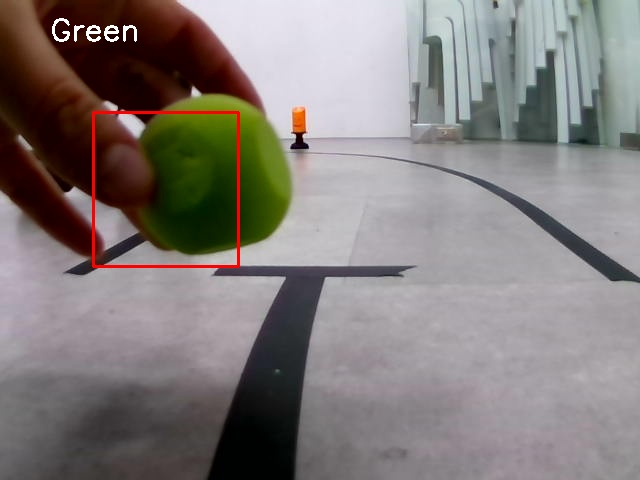

Done


In [ ]:
try:
    # Initial values
    got.screen_display_background(0)
    got.mechanical_joint_control(0, 45, 45, 500)

    ap_approach()
    got.mecanum_move_speed_times(0, 3, 3, 1)
    pickup_ap()
    time.sleep(1)
    got.mecanum_move_speed_times(0, 20, 5, 1)
    

    # # pose control
    # run_pose_control_inline(
    # forward_speed=30,
    # backward_speed=30,
    # turn_speed=45,
    # camera_index=0,
    # model_path="yolov8n-pose.pt",
    # up_margin_factor=0.7,
    # down_margin_factor=0.7,
    # min_conf=0.3,
    # enable_robot=True,
    # debounce_frames=2,
    # max_frames=None,
    # got=got
    # )


    # Street signs
    crossroads = 0

    while crossroads < 2:
        line_type, x, y = line_follow(mult=0.25, speed=20)
        if line_type == 3 and y > 380:
            crossroads += 1
            got.mecanum_move_speed_times(0, 20, 25, 1)
            got.mecanum_turn_speed_times(2, 70, 90, 2)
            time.sleep(0.5)
            text = text_rec()
            if "Red" in text:
                got.screen_display_background(3)
                time.sleep(2)
                # got.mecanum_turn_speed_times(3, 70, 180, 2)
            elif "Green" in text:
                got.screen_display_background(6)
                time.sleep(2)
                # got.mecanum_turn_speed_times(3, 70, 180, 2)
            
            got.mecanum_turn_speed_times(3, 70, 90, 2)

    # # After roads
    # while True:
    #     line_type, x, y = line_follow(mult=0.25, speed=20)
    #     if line_type == 0:
    #         got.mecanum_stop()
    #         break

    # if roads == 1:
    #     got.mecanum_turn_speed_times(3, 60, 90, 2)
    # elif roads == 3:
    #     got.mecanum_turn_speed_times(2, 60, 90, 2)

    # for _ in range(7):
    #     line_follow(mult=0.25, speed=20)

    # got.mecanum_stop()

    # # Face recognition
    # fr = face_rec.WebcamFaceRecognition(known_dir="known")
    # for faces in fr.run_recognition(min_confidence=50, stop_on_name='jensen'):
    #     pass
    #     # print("Detected:", faces)

    got.mecanum_turn_speed_times(3, 60, 30, 2)
    got.screen_display_background(4)
    time.sleep(1)

    # Stop light
    while True:
        color = color_rec()

        if color == "Purple":
            got.screen_display_background(2)
        elif color == "Blue":
            got.screen_display_background(8)
        elif color == "Green":
            got.screen_display_background(6)
            time.sleep(1)
            break
        else:
            got.screen_display_background(0)

    got.mecanum_move_speed_times(0, 20, 10, 1)

finally:
    got.mecanum_stop()
    put_ap()
    print("Done")